In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# CONSTANTS
G = 6.674e-11
M_earth = 5.9722e24
mu_earth = G * M_earth
R_earth = 6.371e6
ALTITUDE = 400_000

def calculate_initial_conditions(altitude):
    r_orbit = R_earth + altitude
    v_circ = np.sqrt(mu_earth / r_orbit)
    r0 = np.array([r_orbit, 0.0])
    v0 = np.array([0.0, v_circ])
    return r0, v0

In [3]:
r0, v0 = calculate_initial_conditions(ALTITUDE)
print(f"Starting point is {r0}")
print(f"Initial Velocity is {v0}")

Starting point is [6771000.       0.]
Initial Velocity is [   0.         7672.44644817]


In [4]:
def acceleration(r):
    # Satellite mass cancels in F=ma — result independent of satellite mass
    # Dividing by r_mag^3 combines magnitude (GM/r^2) and unit direction
    r_mag = np.linalg.norm(r)
    return -(mu_earth / r_mag**3) * r    # Negative sign: acceleration points towards Earth

In [5]:
# Simulation parameters
num_orbits = 5
dt = 10.0
r_orbit = R_earth + ALTITUDE
T_kepler = 2 * np.pi * np.sqrt(r_orbit**3 / mu_earth)
print(f"Period of an orbit is {T_kepler:.1f} s ({T_kepler/60:.2f} min)")
steps = round((num_orbits * T_kepler) / dt)
print(f"Steps: {steps}")

Period of an orbit is 5545.0 s (92.42 min)
Steps: 2772


In [6]:
# r0 and v0 combined into a single 4-element state vector for RK4: [x, y, vx, vy]
initial_state = np.concatenate([r0, v0])

def deriv(state):

    # Extracts position (first two elements) and velocity (last 2 elements)
    r = state[:2]
    v = state[2:]

    # Computes acceleration based on current position
    a = acceleration(r)

    # Returns the derivative of the state: [vx, vy, ax, ay]
    return np.concatenate([v, a])


In [7]:
# RK4 Integration
def rk4step(state, dt):

    # Calculates the four slopes (k1, k2, k3, k4) using the derivative function
    k1 = deriv(state)
    k2 = deriv(state + 0.5 * dt * k1)
    k3 = deriv(state + 0.5 * dt * k2)
    k4 = deriv(state + dt * k3)
    
    # Returns new state by using weighted average of the slopes
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

In [8]:
# Integration Loop
rk4_positions = np.zeros((steps, 2))

s = initial_state.copy()

for i in range(steps):

    # Records the current x,y positions
    rk4_positions[i] = s[:2]

    # Updates the state vector using RK4
    s = rk4step(s, dt)

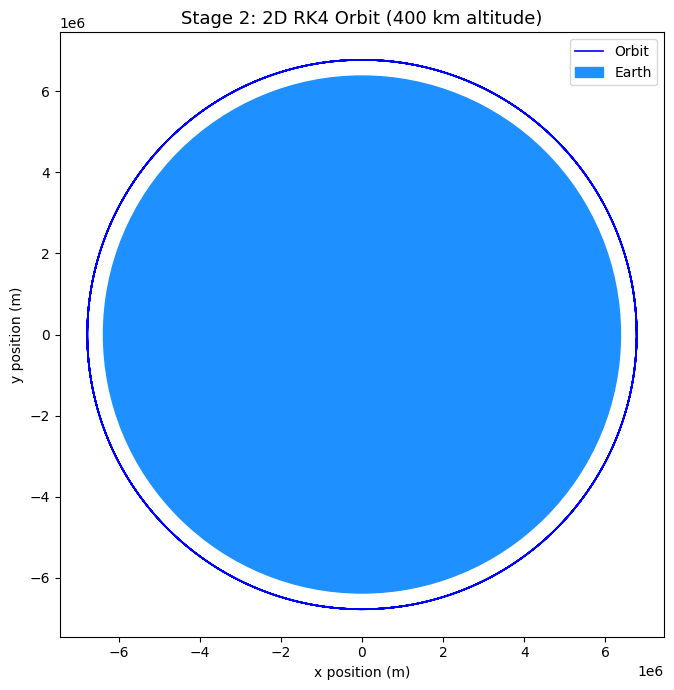

In [9]:
# plot to vizualize RK4
#print(positions[:,0])
x_coords = rk4_positions[:, 0]
y_coords = rk4_positions[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_coords, y_coords, color="blue", lw=1.2, label="Orbit")

# Earth — Radius 6,371,000m
earth = plt.Circle((0,0), R_earth, color="dodgerblue", label="Earth")
ax.add_patch(earth)

ax.set_aspect("equal")
ax.set_title(f"Stage 2: 2D RK4 Orbit ({ALTITUDE/1000:.0f} km altitude)", fontsize=13)
ax.set_xlabel("x position (m)", fontsize=10)
ax.set_ylabel("y position (m)", fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig("../images/stage2_RK4_orbit.png", dpi=150, bbox_inches="tight")
plt.show()